# CNN전이학습_data_augmentation
* 전이학습: 사전에 훈련된 모델을 가져와서 사용하는 것
* data_augmentation: 이미지 데이터의 경우 데이터가 적어서 확보가 어려움, 비쌈이터가 적어서 확보가 어려움, 비쌈, 기존 이미지 데이터에 변형을 가해서 데이터 수를 늘리는 작업(회전, 확대, 축소, 자르기)

# Image Augmentation
* 학습데이터 부족을 해결하기 위해서 이미지에 변형을 가해 새로운 이미지를 만들어 주는 것

In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, array_to_img, load_img

2025-05-20 08:47:02.257981: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-20 08:47:02.269613: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-20 08:47:02.285230: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-20 08:47:02.290488: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-20 08:47:02.300486: I tensorflow/core/platform/cpu_feature_guar

In [2]:
image = load_img("./catanddog/bird.jpg")
image_array = img_to_array(image)
image_array.shape

(703, 454, 3)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

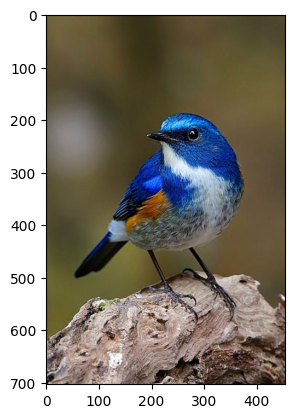

In [4]:
plt.imshow(image)
plt.show()

# Image Augmentation(이미지 증폭)

In [5]:
imggen = ImageDataGenerator(
            rescale= 1./255,
            rotation_range=40,
            width_shift_range=0.3,
            height_shift_range=0.2,
            shear_range=0.6,
            zoom_range=0.3,
            horizontal_flip=True,
            vertical_flip=True,
            fill_mode='nearest'
            )

In [6]:
image_array.shape

(703, 454, 3)

차원 늘리기

In [7]:
# image_array.reshape((1,) + image_array.shape).shape

In [8]:
image_array = image_array.reshape((1,) + image_array.shape)
image_array.shape

(1, 703, 454, 3)

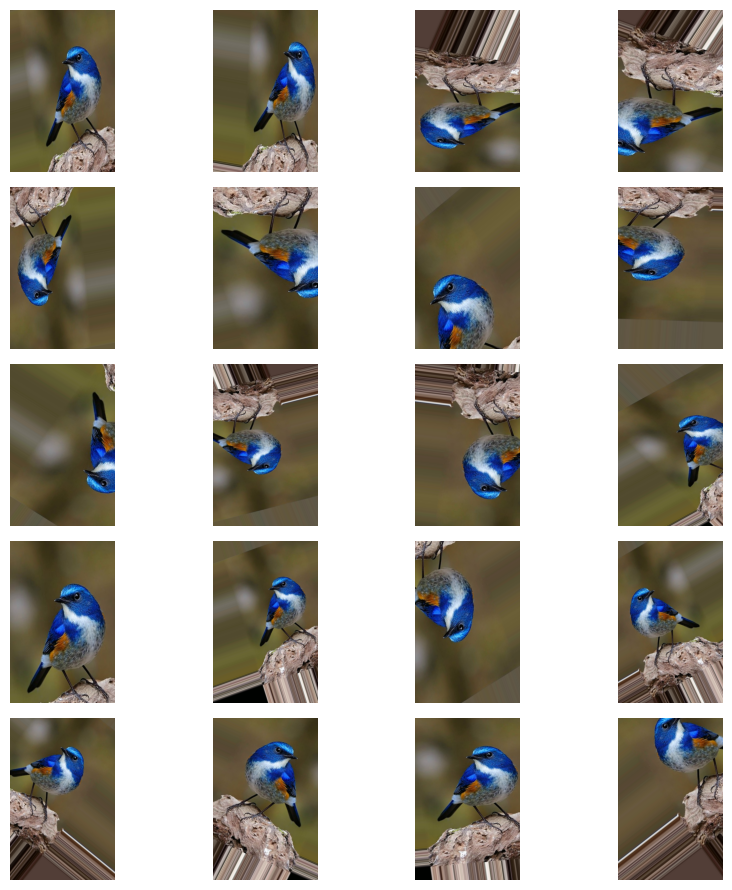

In [9]:
fig, axes = plt.subplots(5, 4, figsize=(9,9))
axes = axes.ravel()

for i, batch in enumerate(imggen.flow(image_array, batch_size=1)):
    if i >= 20:
        break
    augmented_image = array_to_img(batch[0])
    axes[i].imshow(augmented_image)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# image_augmentation을 이용한 개/고양이 분류모델 만들기

In [10]:
# 데이터 로드
train_dir = './catanddog/train/'
valid_dir = './catanddog/validation/'
batch_size = 16 # 한 번에 불러오는 사진의 개수, 분석 모델에 따라서 16(큼) ~ 32(작음) 사이로 지정
image_size = (224, 224) # 모델의 입력 크기에 맞춤

In [11]:
# 이미지 증강
train_aug = ImageDataGenerator(
            rescale=1./255,
            rotation_range=40,
            width_shift_range=0.3,
            height_shift_range=0.2,
            shear_range=0.6,
            zoom_range=0.3,
            fill_mode='nearest')

valid_aug = ImageDataGenerator(rescale=1./255)

# 이미지 제너레이터
train_gen = train_aug.flow_from_directory(
            train_dir,
            target_size=image_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=True,
            seed=42)

valid_gen = valid_aug.flow_from_directory(
            valid_dir,
            target_size=image_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=True,
            seed=42)


X_batch, y_batch = next(train_gen)
print(X_batch.shape)
print(y_batch.shape)
print(train_gen.class_indices)

Found 2222 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
(16, 224, 224, 3)
(16, 2)
{'Cat': 0, 'Dog': 1}


# CNN을 이용한 개/고양이 분류

In [12]:
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [13]:
cnn_model = Sequential()
cnn_model.add(Input(shape=(224,224,3)))
cnn_model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
cnn_model.add(MaxPooling2D(2,2))
cnn_model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
cnn_model.add(MaxPooling2D(2,2))
cnn_model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
cnn_model.add(MaxPooling2D(2,2))
cnn_model.add(Flatten())
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.25))
cnn_model.add(Dense(64, activation='relu'))
cnn_model.add(Dense(2, activation='softmax'))
cnn_model.summary()

I0000 00:00:1747730828.051966     223 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1747730828.057470     223 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1747730828.057507     223 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1747730828.060319     223 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1747730828.060354     223 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 21632)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,769,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,815,266 (10.74 MB)

 Trainable params: 2,815,266 (10.74 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
import tensorflow as tf

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/1000


I0000 00:00:1747730831.013994     295 service.cc:146] XLA service 0x7fec3800cc90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747730831.014047     295 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce MX450, Compute Capability 7.5
2025-05-20 08:47:11.061168: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-05-20 08:47:11.328253: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8906
E0000 00:00:1747730833.875891     295 gpu_timer.cc:183] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1747730834.081411     295 gpu_timer.cc:183] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  2/139 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - accuracy: 0.4688 - loss: 0.7063 

I0000 00:00:1747730837.958608     295 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


...

139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 583ms/step - accuracy: 0.5090 - loss: 0.6954
Epoch 1: val_loss improved from inf to 0.68637, saving model to ./model/cnn_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 104s 689ms/step - accuracy: 0.5091 - loss: 0.6954 - val_accuracy: 0.5000 - val_loss: 0.6864
Epoch 2/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.5228 - loss: 0.6907
Epoch 2: val_loss did not improve from 0.68637
139/139 ━━━━━━━━━━━━━━━━━━━━ 63s 451ms/step - accuracy: 0.5229 - loss: 0.6907 - val_accuracy: 0.5714 - val_loss: 0.6930
Epoch 3/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.5436 - loss: 0.6848
Epoch 3: val_loss improved from 0.68637 to 0.66704, saving model to ./model/cnn_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 62s 441ms/step - accuracy: 0.5436 - loss: 0.6848 - val_accuracy: 0.5408 - val_loss: 0.6670
Epoch 4/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.5472 - loss: 0.6814
Epoch 4: val_loss improved from 0.66704 to 0.64274, saving mo

Epoch 25/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.6878 - loss: 0.5942
Epoch 25: val_loss improved from 0.57609 to 0.56628, saving model to ./model/cnn_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 38s 272ms/step - accuracy: 0.6877 - loss: 0.5943 - val_accuracy: 0.6735 - val_loss: 0.5663
Epoch 26/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - accuracy: 0.6811 - loss: 0.6058
Epoch 26: val_loss did not improve from 0.56628
139/139 ━━━━━━━━━━━━━━━━━━━━ 39s 278ms/step - accuracy: 0.6810 - loss: 0.6058 - val_accuracy: 0.6327 - val_loss: 0.6008
Epoch 27/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.6709 - loss: 0.6020
Epoch 27: val_loss did not improve from 0.56628
139/139 ━━━━━━━━━━━━━━━━━━━━ 40s 273ms/step - accuracy: 0.6710 - loss: 0.6020 - val_accuracy: 0.7041 - val_loss: 0.5902
Epoch 28/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.6875 - loss: 0.5869
Epoch 28: val_loss did not improve from 0.56628
139/139 ━━━━━━━━━━━━━━━━━━━━ 37s 267m

139/139 ━━━━━━━━━━━━━━━━━━━━ 40s 286ms/step - accuracy: 0.7208 - loss: 0.5546 - val_accuracy: 0.6735 - val_loss: 0.5352
Epoch 50/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.7327 - loss: 0.5421
Epoch 50: val_loss did not improve from 0.53517
139/139 ━━━━━━━━━━━━━━━━━━━━ 37s 264ms/step - accuracy: 0.7326 - loss: 0.5420 - val_accuracy: 0.6633 - val_loss: 0.5463
Epoch 51/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.7429 - loss: 0.5242
Epoch 51: val_loss did not improve from 0.53517
139/139 ━━━━━━━━━━━━━━━━━━━━ 37s 267ms/step - accuracy: 0.7429 - loss: 0.5243 - val_accuracy: 0.7347 - val_loss: 0.5463
Epoch 52/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.7243 - loss: 0.5376
Epoch 52: val_loss did not improve from 0.53517
139/139 ━━━━━━━━━━━━━━━━━━━━ 37s 266ms/step - accuracy: 0.7243 - loss: 0.5376 - val_accuracy: 0.7143 - val_loss: 0.5472
Epoch 53/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.7548 - loss: 0.5099
Epoch 53: va

Epoch 99/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.7820 - loss: 0.4445
Epoch 99: val_loss improved from 0.51305 to 0.49767, saving model to ./model/cnn_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 47s 334ms/step - accuracy: 0.7820 - loss: 0.4445 - val_accuracy: 0.7245 - val_loss: 0.4977
Epoch 100/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.7799 - loss: 0.4554
Epoch 100: val_loss did not improve from 0.49767
139/139 ━━━━━━━━━━━━━━━━━━━━ 48s 342ms/step - accuracy: 0.7799 - loss: 0.4555 - val_accuracy: 0.7143 - val_loss: 0.5569
Epoch 101/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - accuracy: 0.7938 - loss: 0.4421
Epoch 101: val_loss did not improve from 0.49767
139/139 ━━━━━━━━━━━━━━━━━━━━ 45s 320ms/step - accuracy: 0.7938 - loss: 0.4422 - val_accuracy: 0.6735 - val_loss: 0.5667
Epoch 102/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.7997 - loss: 0.4410
Epoch 102: val_loss did not improve from 0.49767
139/139 ━━━━━━━━━━━━━━━━━━━━ 42

Epoch 124/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.7993 - loss: 0.4169
Epoch 124: val_loss did not improve from 0.48628
139/139 ━━━━━━━━━━━━━━━━━━━━ 38s 269ms/step - accuracy: 0.7993 - loss: 0.4169 - val_accuracy: 0.6837 - val_loss: 0.5579
Epoch 124: early stopping
Restoring model weights from the end of the best epoch: 104.


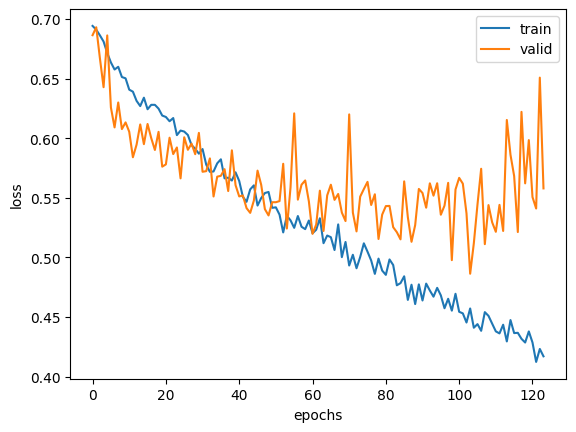

In [15]:
cnn_model.compile(loss='categorical_crossentropy', 
                  optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  metrics=['accuracy'])
model_path = "./model/cnn_catndog.keras"
check_point = ModelCheckpoint(model_path, save_best_only=True, monitor='val_loss', verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)
cnn_history = cnn_model.fit(train_gen, epochs=1000, validation_data=valid_gen,
                           callbacks=[early_stop, check_point])
plt.plot(cnn_history.history['loss'])
plt.plot(cnn_history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'valid'])
plt.show()

In [16]:
class_indices = valid_gen.class_indices
class_indices

{'Cat': 0, 'Dog': 1}

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step


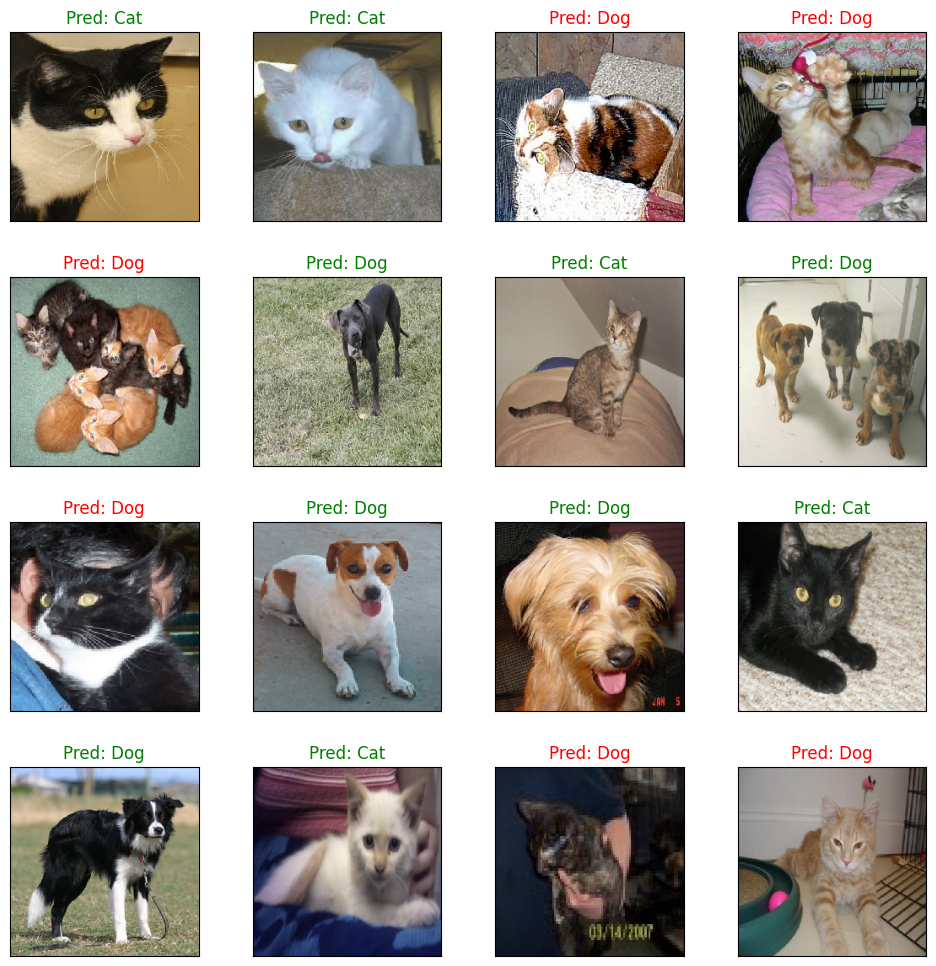


cnn_best_model평가 결과: Loss: 0.5738, Accuracy: 0.6250


In [17]:
# best 모델 로드
cnn_best_model = load_model("./model/cnn_catndog.keras")

# 클래스 이름 추출하기
class_indices = valid_gen.class_indices
class_names = [k for k, v in sorted(class_indices.items(), key=lambda x: x[1])]
validation_batch, label_batch = next(iter(valid_gen))

cnn_pred = cnn_best_model.predict(validation_batch)
pred_values = np.argmax(cnn_pred, axis=1)
true_values = np.argmax(label_batch, axis=1)

fig = plt.figure(figsize=(12,12))
fig.subplots_adjust(hspace=0.3)

num_images = min(16, validation_batch.shape[0])

for i in range(num_images):
    ax = fig.add_subplot(4, 4, i + 1, xticks=[], yticks=[])
    ax.imshow(validation_batch[i], cmap=plt.cm.gray_r)
    
    pred_label = class_names[pred_values[i]]
    true_label = class_names[true_values[i]]
    color = 'green' if pred_values[i] == true_values[i] else 'red'
    ax.set_title(f"Pred: {pred_label}", color=color, fontsize=12)
plt.show()

# loss와 accuracy 출력
loss, acc = cnn_best_model.evaluate(validation_batch, label_batch, verbose=0)
print(f"\ncnn_best_model평가 결과: Loss: {loss:.4f}, Accuracy: {acc:.4f}")

# 전이학습
* 사전에 훈련된 모델을 가지고 새로운 데이터를 넣어서 튜닝을 하거나 결과를 출력
* keras.applications에 있음

# ResNet50
* ResNet50에 사용할 경우, rescale=1./255는 제거하고 preprocessing_function=preprocess_input을 사용
* keras의 ResNet50은 입력 이미지를 BGR로 바꾸고 채널별 평균을 빼는 전처리를 필요로 하기 때문

In [18]:
from tensorflow.keras.layers import GlobalMaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50, ResNet152V2
from tensorflow.keras.applications.resnet import preprocess_input
import tesorflow as tf

In [19]:
base_model = ResNet50(
    include_top=False,
    weights='imagenet',
    input_tensor=None,
    input_shape=(224,224,3),
    pooling='avg')

In [20]:
base_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [21]:
base_model.trainable = False
res50_model = Sequential()
res50_model.add(base_model)
res50_model.add(Dense(2, activation='softmax'))
res50_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │         4,098 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,591,810 (90.00 MB)

 Trainable params: 4,098 (16.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [22]:
res50_model.compile(loss='categorical_crossentropy', 
                  optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  metrics=['accuracy'])
model_path = "./model/res50_catndog.keras"
check_point = ModelCheckpoint(model_path, save_best_only=True, monitor='val_loss', verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)
res50_history = res50_model.fit(train_gen, epochs=1000, validation_data=valid_gen,
                           callbacks=[early_stop, check_point])
plt.plot(res50_history.history['loss'])
plt.plot(res50_history.history['val_loss'])
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend(['train', 'valid'])
plt.show()

Epoch 1/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 554ms/step - accuracy: 0.5192 - loss: 0.6927
Epoch 1: val_loss improved from inf to 0.68496, saving model to ./model/res50_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 105s 663ms/step - accuracy: 0.5191 - loss: 0.6927 - val_accuracy: 0.5102 - val_loss: 0.6850
Epoch 2/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 528ms/step - accuracy: 0.5332 - loss: 0.6919
Epoch 2: val_loss improved from 0.68496 to 0.68304, saving model to ./model/res50_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 78s 560ms/step - accuracy: 0.5332 - loss: 0.6919 - val_accuracy: 0.6020 - val_loss: 0.6830
Epoch 3/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - accuracy: 0.5339 - loss: 0.6916
Epoch 3: val_loss improved from 0.68304 to 0.68172, saving model to ./model/res50_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 83s 595ms/step - accuracy: 0.5339 - loss: 0.6916 - val_accuracy: 0.6020 - val_loss: 0.6817
Epoch 4/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - accuracy: 0.5211 - loss: 0.

Epoch 24/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 534ms/step - accuracy: 0.5409 - loss: 0.6873
Epoch 24: val_loss did not improve from 0.67295
139/139 ━━━━━━━━━━━━━━━━━━━━ 76s 548ms/step - accuracy: 0.5408 - loss: 0.6873 - val_accuracy: 0.6020 - val_loss: 0.6733
Epoch 25/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 542ms/step - accuracy: 0.5364 - loss: 0.6883
Epoch 25: val_loss did not improve from 0.67295
139/139 ━━━━━━━━━━━━━━━━━━━━ 77s 553ms/step - accuracy: 0.5364 - loss: 0.6883 - val_accuracy: 0.5612 - val_loss: 0.6744
Epoch 26/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 557ms/step - accuracy: 0.5467 - loss: 0.6904
Epoch 26: val_loss improved from 0.67295 to 0.67248, saving model to ./model/res50_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 82s 588ms/step - accuracy: 0.5467 - loss: 0.6904 - val_accuracy: 0.6735 - val_loss: 0.6725
Epoch 27/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.5348 - loss: 0.6899
Epoch 27: val_loss did not improve from 0.67248
139/139 ━━━━━━━━━━━━━━━━━━━━ 82s 58

Epoch 48/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - accuracy: 0.5364 - loss: 0.6887
Epoch 48: val_loss did not improve from 0.66781
139/139 ━━━━━━━━━━━━━━━━━━━━ 78s 562ms/step - accuracy: 0.5364 - loss: 0.6887 - val_accuracy: 0.5408 - val_loss: 0.6711
Epoch 49/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 560ms/step - accuracy: 0.5382 - loss: 0.6869
Epoch 49: val_loss improved from 0.66781 to 0.66711, saving model to ./model/res50_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 83s 595ms/step - accuracy: 0.5383 - loss: 0.6869 - val_accuracy: 0.6735 - val_loss: 0.6671
Epoch 50/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 549ms/step - accuracy: 0.5477 - loss: 0.6870
Epoch 50: val_loss did not improve from 0.66711
139/139 ━━━━━━━━━━━━━━━━━━━━ 79s 564ms/step - accuracy: 0.5476 - loss: 0.6870 - val_accuracy: 0.6531 - val_loss: 0.6673
Epoch 51/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 570ms/step - accuracy: 0.5317 - loss: 0.6868
Epoch 51: val_loss did not improve from 0.66711
139/139 ━━━━━━━━━━━━━━━━━━━━ 82s 58

Epoch 72/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 559ms/step - accuracy: 0.6045 - loss: 0.6755
Epoch 72: val_loss improved from 0.66457 to 0.66448, saving model to ./model/res50_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 84s 597ms/step - accuracy: 0.6042 - loss: 0.6755 - val_accuracy: 0.6531 - val_loss: 0.6645
Epoch 73/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 557ms/step - accuracy: 0.5649 - loss: 0.6825
Epoch 73: val_loss did not improve from 0.66448
139/139 ━━━━━━━━━━━━━━━━━━━━ 81s 583ms/step - accuracy: 0.5648 - loss: 0.6825 - val_accuracy: 0.6122 - val_loss: 0.6666
Epoch 74/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - accuracy: 0.5514 - loss: 0.6867
Epoch 74: val_loss did not improve from 0.66448
139/139 ━━━━━━━━━━━━━━━━━━━━ 81s 581ms/step - accuracy: 0.5514 - loss: 0.6867 - val_accuracy: 0.6531 - val_loss: 0.6657
Epoch 75/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 553ms/step - accuracy: 0.5448 - loss: 0.6855
Epoch 75: val_loss did not improve from 0.66448
139/139 ━━━━━━━━━━━━━━━━━━━━ 81s 58

139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 545ms/step - accuracy: 0.5448 - loss: 0.6864
Epoch 96: val_loss did not improve from 0.66254
139/139 ━━━━━━━━━━━━━━━━━━━━ 80s 572ms/step - accuracy: 0.5449 - loss: 0.6864 - val_accuracy: 0.5204 - val_loss: 0.6687
Epoch 97/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 538ms/step - accuracy: 0.5466 - loss: 0.6883
Epoch 97: val_loss did not improve from 0.66254
139/139 ━━━━━━━━━━━━━━━━━━━━ 79s 563ms/step - accuracy: 0.5467 - loss: 0.6883 - val_accuracy: 0.6531 - val_loss: 0.6628
Epoch 98/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 537ms/step - accuracy: 0.5862 - loss: 0.6772
Epoch 98: val_loss improved from 0.66254 to 0.66175, saving model to ./model/res50_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 81s 577ms/step - accuracy: 0.5860 - loss: 0.6772 - val_accuracy: 0.6633 - val_loss: 0.6618
Epoch 99/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 535ms/step - accuracy: 0.5552 - loss: 0.6839
Epoch 99: val_loss improved from 0.66175 to 0.66158, saving model to ./model/res50_catndog.keras


...

139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 566ms/step - accuracy: 0.5756 - loss: 0.6783
Epoch 240: val_loss did not improve from 0.65250
139/139 ━━━━━━━━━━━━━━━━━━━━ 81s 579ms/step - accuracy: 0.5755 - loss: 0.6784 - val_accuracy: 0.6633 - val_loss: 0.6527
Epoch 241/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 556ms/step - accuracy: 0.5842 - loss: 0.6733
Epoch 241: val_loss improved from 0.65250 to 0.65189, saving model to ./model/res50_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 82s 592ms/step - accuracy: 0.5841 - loss: 0.6733 - val_accuracy: 0.6735 - val_loss: 0.6519
Epoch 242/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 577ms/step - accuracy: 0.5800 - loss: 0.6735
Epoch 242: val_loss did not improve from 0.65189
139/139 ━━━━━━━━━━━━━━━━━━━━ 82s 588ms/step - accuracy: 0.5799 - loss: 0.6735 - val_accuracy: 0.6939 - val_loss: 0.6524
Epoch 243/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 566ms/step - accuracy: 0.5666 - loss: 0.6762
Epoch 243: val_loss did not improve from 0.65189
139/139 ━━━━━━━━━━━━━━━━━━━━ 80s 577ms/ste

139/139 ━━━━━━━━━━━━━━━━━━━━ 81s 581ms/step - accuracy: 0.5789 - loss: 0.6755 - val_accuracy: 0.6837 - val_loss: 0.6519
Epoch 265/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - accuracy: 0.5853 - loss: 0.6755
Epoch 265: val_loss did not improve from 0.65175
139/139 ━━━━━━━━━━━━━━━━━━━━ 81s 578ms/step - accuracy: 0.5853 - loss: 0.6755 - val_accuracy: 0.5408 - val_loss: 0.6592
Epoch 266/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 548ms/step - accuracy: 0.5583 - loss: 0.6784
Epoch 266: val_loss did not improve from 0.65175
139/139 ━━━━━━━━━━━━━━━━━━━━ 80s 573ms/step - accuracy: 0.5583 - loss: 0.6784 - val_accuracy: 0.6429 - val_loss: 0.6526
Epoch 267/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 549ms/step - accuracy: 0.5682 - loss: 0.6796
Epoch 267: val_loss did not improve from 0.65175
139/139 ━━━━━━━━━━━━━━━━━━━━ 80s 575ms/step - accuracy: 0.5683 - loss: 0.6796 - val_accuracy: 0.6837 - val_loss: 0.6530
Epoch 268/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 548ms/step - accuracy: 0.5664 - loss: 0.6789
Epoch

139/139 ━━━━━━━━━━━━━━━━━━━━ 81s 577ms/step - accuracy: 0.5457 - loss: 0.6819 - val_accuracy: 0.6122 - val_loss: 0.6529
Epoch 289/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - accuracy: 0.5541 - loss: 0.6792
Epoch 289: val_loss did not improve from 0.64949
139/139 ━━━━━━━━━━━━━━━━━━━━ 82s 579ms/step - accuracy: 0.5541 - loss: 0.6792 - val_accuracy: 0.6837 - val_loss: 0.6496
Epoch 290/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 551ms/step - accuracy: 0.5816 - loss: 0.6775
Epoch 290: val_loss improved from 0.64949 to 0.64944, saving model to ./model/res50_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 82s 586ms/step - accuracy: 0.5816 - loss: 0.6775 - val_accuracy: 0.6837 - val_loss: 0.6494
Epoch 291/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 551ms/step - accuracy: 0.5584 - loss: 0.6795
Epoch 291: val_loss did not improve from 0.64944
139/139 ━━━━━━━━━━━━━━━━━━━━ 81s 576ms/step - accuracy: 0.5583 - loss: 0.6795 - val_accuracy: 0.5816 - val_loss: 0.6551
Epoch 292/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 5

Epoch 313/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5604 - loss: 0.6816
Epoch 313: val_loss did not improve from 0.64852
139/139 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step - accuracy: 0.5604 - loss: 0.6816 - val_accuracy: 0.6735 - val_loss: 0.6485
Epoch 314/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5782 - loss: 0.6744
Epoch 314: val_loss improved from 0.64852 to 0.64847, saving model to ./model/res50_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 166s 1s/step - accuracy: 0.5782 - loss: 0.6744 - val_accuracy: 0.6735 - val_loss: 0.6485
Epoch 315/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5773 - loss: 0.6764
Epoch 315: val_loss did not improve from 0.64847
139/139 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.5773 - loss: 0.6764 - val_accuracy: 0.6327 - val_loss: 0.6499
Epoch 316/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5758 - loss: 0.6756
Epoch 316: val_loss did not improve from 0.64847
139/139 ━━━━━━━━━━━━━━━━━━━━ 157s 1s/step - a

KeyboardInterrupt: 

In [ ]:
# best 모델 로드
res50_best_model = load_model("./model/res50_catndog.keras")

# 클래스 이름 추출하기
class_indices = valid_gen.class_indices
class_names = [k for k, v in sorted(class_indices.items(), key=lambda x: x[1])]
validation_batch, label_batch = next(iter(valid_gen))

res50_pred = res50_best_model.predict(validation_batch)
pred_values = np.argmax(res50_pred, axis=1)
true_values = np.argmax(label_batch, axis=1)

fig = plt.figure(figsize=(12,12))
fig.subplots_adjust(hspace=0.3)

num_images = min(16, validation_batch.shape[0])

for i in range(num_images):
    ax = fig.add_subplot(4, 4, i + 1, xticks=[], yticks=[])
    ax.imshow(validation_batch[i], cmap=plt.cm.gray_r)
    
    pred_label = class_names[pred_values[i]]
    true_label = class_names[true_values[i]]
    color = 'green' if pred_values[i] == true_values[i] else 'red'
    ax.set_title(f"Pred: {pred_label}", color=color, fontsize=12)
plt.show()

# loss와 accuracy 출력
loss, acc = res50_best_model.evaluate(validation_batch, label_batch, verbose=0)
print(f"\nres50_best_model 평가 결과: Loss: {loss:.4f}, Accuracy: {acc:.4f}")

# ResNet152V2

In [ ]:
base_model2 = ResNet152V2(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3),
    pooling='avg'
)

In [ ]:
base_model2.summary()

In [ ]:
base_model2.trainable = False
res152v2_model = Sequential()
res152v2_model.add(base_model2)
res152v2_model.add(Dense(2, activation="softmax"))

In [ ]:
res152v2_model.compile(loss='categorical_crossentropy', 
                  optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  metrics=['accuracy'])
model_path = "./model/res152v2_catndog.keras"
check_point = ModelCheckpoint(model_path, save_best_only=True, monitor='val_loss', verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
res152v2_history = res152v2_model.fit(train_gen, epochs=1000, validation_data=valid_gen,
                           callbacks=[early_stop, check_point])
plt.plot(res152v2_history.history['loss'])
plt.plot(res152v2_history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'valid'])
plt.show()

In [ ]:
# best 모델 로드
res152v2_best_model = load_model("./model/res152v2_catndog.keras")

# 클래스 이름 추출하기
class_indices = valid_gen.class_indices
class_names = [k for k, v in sorted(class_indices.items(), key=lambda x: x[1])]
validation_batch, label_batch = next(iter(valid_gen))

res152v2_pred = res152v2_best_model.predict(validation_batch)
pred_values = np.argmax(res152v2_pred, axis=1)
true_values = np.argmax(label_batch, axis=1)

fig = plt.figure(figsize=(12,12))
fig.subplots_adjust(hspace=0.3)

num_images = min(16, validation_batch.shape[0])

for i in range(num_images):
    ax = fig.add_subplot(4, 4, i + 1, xticks=[], yticks=[])
    ax.imshow(validation_batch[i], cmap=plt.cm.gray_r)
    
    pred_label = class_names[pred_values[i]]
    true_label = class_names[true_values[i]]
    color = 'green' if pred_values[i] == true_values[i] else 'red'
    ax.set_title(f"Pred: {pred_label}", color=color, fontsize=12)
plt.show()

# loss와 accuracy 출력
loss, acc = res152v2_best_model.evaluate(validation_batch, label_batch, verbose=0)
print(f"\nres152v2_best_model평가 결과: Loss: {loss:.4f}, Accuracy: {acc:.4f}")

# convnextbase로 분석하기

In [ ]:
from tensorflow.keras.applications import ConvNeXtBase

In [ ]:
# 이미지 증강
train_aug2 = ImageDataGenerator(
            rotation_range=40,
            width_shift_range=0.3,
            height_shift_range=0.2,
            shear_range=0.6,
            zoom_range=0.3,
            fill_mode='nearest')

valid_aug2 = ImageDataGenerator()

# 이미지 제너레이터
train_gen2 = train_aug2.flow_from_directory(
            train_dir,
            target_size=image_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=True,
            seed=42)

valid_gen2 = valid_aug2.flow_from_directory(
            valid_dir,
            target_size=image_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=True,
            seed=42)


X_batch2, y_batch2 = next(train_gen2)
print(X_batch2.shape)
print(y_batch2.shape)
print(train_gen2.class_indices)

In [ ]:
base_model3 = ConvNeXtBase(
    include_top=True,
    include_preprocessing=True,
    weights="imagenet",
    input_shape=(224,224,3),
    pooling='avg',
    classes=1000,
    classifier_activation="softmax",
    name="convnext_base",
)

In [ ]:
base_model3.trainable = False
ConvNeXtBase_model = Sequential()
ConvNeXtBase_model.add(base_model3)
ConvNeXtBase_model.add(Dense(2, activation="softmax"))

In [ ]:
ConvNeXtBase_model.compile(loss='categorical_crossentropy', 
                  optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  metrics=['accuracy'])
model_path = "./model/ConvNeXtBase_catndog.keras"
check_point = ModelCheckpoint(model_path, save_best_only=True, monitor='val_loss', verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
ConvNeXtBase_history = ConvNeXtBase_model.fit(train_gen2, epochs=1000, validation_data=valid_gen,
                           callbacks=[early_stop, check_point])
plt.plot(ConvNeXtBase_history.history['loss'])
plt.plot(ConvNeXtBase_history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'valid'])
plt.show()

In [ ]:
# best 모델 로드
ConvNeXtBase_best_model = load_model("./model/ConvNeXtBase_catndog.keras")

# 클래스 이름 추출하기
class_indices = valid_gen2.class_indices
class_names = [k for k, v in sorted(class_indices.items(), key=lambda x: x[1])]
validation_batch, label_batch = next(iter(valid_gen2))

ConvNeXtBase_pred = ConvNeXtBase_best_model.predict(validation_batch)
pred_values = np.argmax(ConvNeXtBase_pred, axis=1)
true_values = np.argmax(label_batch, axis=1)

fig = plt.figure(figsize=(12,12))
fig.subplots_adjust(hspace=0.3)

num_images = min(16, validation_batch.shape[0])

for i in range(num_images):
    ax = fig.add_subplot(4, 4, i + 1, xticks=[], yticks=[])
    ax.imshow(validation_batch[i], cmap=plt.cm.gray_r)
    
    pred_label = class_names[pred_values[i]]
    true_label = class_names[true_values[i]]
    color = 'green' if pred_values[i] == true_values[i] else 'red'
    ax.set_title(f"Pred: {pred_label}", color=color, fontsize=12)
plt.show()

# loss와 accuracy 출력
loss, acc = ConvNeXtBase_best_model.evaluate(validation_batch, label_batch, verbose=0)
print(f"\nConvNeXtBase_best_model 평가 결과: Loss: {loss:.4f}, Accuracy: {acc:.4f}")